# All Tasks: Algorithm Comparison Plots

Comparison of 9 imitation learning algorithms (1 expert + 4 causal + 4 naive) evaluated on 1000 episodes each across AntMaze-Large and AntMaze-Medium.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "figure.dpi": 150,
})

PLOTS_DIR = '/home/et2842/causal/causalrl/examples/experiments/plots/all-tasks'

In [2]:
# --- Data extracted from out_test_*.ipynb notebooks (1000 eval episodes each) ---

antlarge_algorithms = [
    'Expert',
    'Causal BC', 'Causal GAIL', 'Causal SQIL', 'Causal IQLearn',
    'Naive BC',  'Naive GAIL',  'Naive SQIL',  'Naive IQLearn',
]

# E[Y] and Std[Y]
antlarge_mean_rewards = np.array([
    -255.2071,   # Expert
    -317.5099,   # Causal BC
    -369.7720,   # Causal GAIL
    -276.0272,   # Causal SQIL
    -283.1393,   # Causal IQLearn
    -470.2175,   # Naive BC
    -398.3703,   # Naive GAIL
    -484.1541,   # Naive SQIL
    -468.0926,   # Naive IQLearn
])

antlarge_std_rewards = np.array([
    122.7925,    # Expert
    123.8694,    # Causal BC
    127.9221,    # Causal GAIL
    125.4018,    # Causal SQIL
    130.0205,    # Causal IQLearn
    150.1761,    # Naive BC
    132.9128,    # Naive GAIL
    151.4962,    # Naive SQIL
    153.4817,    # Naive IQLearn
])

# Success rates and standard errors
antlarge_success_rates = np.array([
    55.90,  # Expert
    39.80,  # Causal BC
     0.10,  # Causal GAIL
    45.00,  # Causal SQIL
    58.90,  # Causal IQLearn
     0.00,  # Naive BC
     0.00,  # Naive GAIL
     0.00,  # Naive SQIL
     0.00,  # Naive IQLearn
])

antlarge_success_se = np.array([
    1.57,  # Expert
    1.28,  # Causal BC
    0.10,  # Causal GAIL
    1.56,  # Causal SQIL
    1.58,  # Causal IQLearn
    0.00,  # Naive BC
    0.00,  # Naive GAIL
    0.00,  # Naive SQIL
    0.00,  # Naive IQLearn
])

# Successful episode lengths (mean, std) — only for algorithms with successes
antlarge_succ_len_mean = np.array([
    647.49,  # Expert
    731.97,  # Causal BC
    550.00,  # Causal GAIL (1 episode)
    677.18,  # Causal SQIL
    688.73,  # Causal IQLearn
    np.nan,  # Naive BC
    np.nan,  # Naive GAIL
    np.nan,  # Naive SQIL
    np.nan,  # Naive IQLearn
])

antlarge_succ_len_std = np.array([
    99.00,   # Expert
    120.96,  # Causal BC
    0.00,    # Causal GAIL (1 episode)
    126.58,  # Causal SQIL
    111.64,  # Causal IQLearn
    np.nan,  # Naive BC
    np.nan,  # Naive GAIL
    np.nan,  # Naive SQIL
    np.nan,  # Naive IQLearn
])

# Green color palette — dark greens for Expert/Causal, lighter greens for Naive
antlarge_colors = [
    '#1B4332',  # Expert — darkest green
    '#2D6A4F',  # Causal BC
    '#40916C',  # Causal GAIL
    '#52B788',  # Causal SQIL
    '#74C69D',  # Causal IQLearn
    '#95D5B2',  # Naive BC
    '#B7E4C7',  # Naive GAIL
    '#D8F3DC',  # Naive SQIL
    '#E8F8EE',  # Naive IQLearn
]

x = np.arange(len(antlarge_algorithms))

In [3]:
# --- AntMaze-Medium data (from plots_antmed.ipynb) ---

antmed_algorithms = [
    'Expert',
    'Causal BC', 'Causal GAIL', 'Causal SQIL', 'Causal IQLearn',
    'Naive BC',  'Naive GAIL',  'Naive SQIL',  'Naive IQLearn',
]

antmed_mean_rewards = np.array([
    -103.9545,   # Expert
    -154.0120,   # Causal BC
    -186.0156,   # Causal GAIL
    -135.9300,   # Causal SQIL
    -142.4897,   # Causal IQLearn
    -375.3281,   # Naive BC
    -364.8926,   # Naive GAIL
    -370.6745,   # Naive SQIL
    -372.5462,   # Naive IQLearn
])

antmed_std_rewards = np.array([
    87.5173,     # Expert
    113.8964,    # Causal BC
    122.9877,    # Causal GAIL
    110.0002,    # Causal SQIL
    111.5273,    # Causal IQLearn
    119.1750,    # Naive BC
    112.2076,    # Naive GAIL
    119.0691,    # Naive SQIL
    120.8261,    # Naive IQLearn
])

antmed_success_rates = np.array([
    87.60,  # Expert
    77.90,  # Causal BC
    74.10,  # Causal GAIL
    90.70,  # Causal SQIL
    84.30,  # Causal IQLearn
    0.00,   # Naive BC
    0.00,   # Naive GAIL
    0.00,   # Naive SQIL
    0.00,   # Naive IQLearn
])

antmed_success_se = np.array([
    1.04,  # Expert
    1.50,  # Causal BC
    1.56,  # Causal GAIL
    1.34,  # Causal SQIL
    1.39,  # Causal IQLearn
    0.00,  # Naive BC
    0.00,  # Naive GAIL
    0.00,  # Naive SQIL
    0.00,  # Naive IQLearn
])

antmed_succ_len_mean = np.array([
    301.34,  # Expert
    357.84,  # Causal BC
    390.39,  # Causal GAIL
    330.74,  # Causal SQIL
    351.47,  # Causal IQLearn
    np.nan,  # Naive BC
    np.nan,  # Naive GAIL
    np.nan,  # Naive SQIL
    np.nan,  # Naive IQLearn
])

antmed_succ_len_std = np.array([
    57.08,   # Expert
    112.12,  # Causal BC
    119.09,  # Causal GAIL
    91.18,   # Causal SQIL
    86.38,   # Causal IQLearn
    np.nan,  # Naive BC
    np.nan,  # Naive GAIL
    np.nan,  # Naive SQIL
    np.nan,  # Naive IQLearn
])

antmed_colors = [
    '#082B47',  # Expert — darkest navy
    '#0A5E8C',  # Causal BC
    '#1976B0',  # Causal GAIL
    '#2B8CC4',  # Causal SQIL
    '#4BA3D8',  # Causal IQLearn
    '#7BBDE5',  # Naive BC
    '#9ED0EE',  # Naive GAIL
    '#BDE0F5',  # Naive SQIL
    '#D6ECF9',  # Naive IQLearn
]

In [4]:
# --- Data extracted from out_test_*.ipynb notebooks (1000 eval episodes each) ---

hummed_algorithms = [
    'Expert',
    'Causal BC', 'Causal GAIL', 'Causal SQIL', 'Causal IQLearn',
    'Naive BC',  'Naive GAIL',  'Naive SQIL',  'Naive IQLearn',
]

# Success rates and standard errors
hummed_success_rates = np.array([
    33.80,  # Expert
    10.40,  # Causal BC
     0.00,  # Causal GAIL
    24.70,  # Causal SQIL
    19.10,  # Causal IQLearn
     5.40,  # Naive BC
     0.00,  # Naive GAIL
     0.10,  # Naive SQIL
     2.40,  # Naive IQLearn
])

x = np.arange(len(antlarge_algorithms))

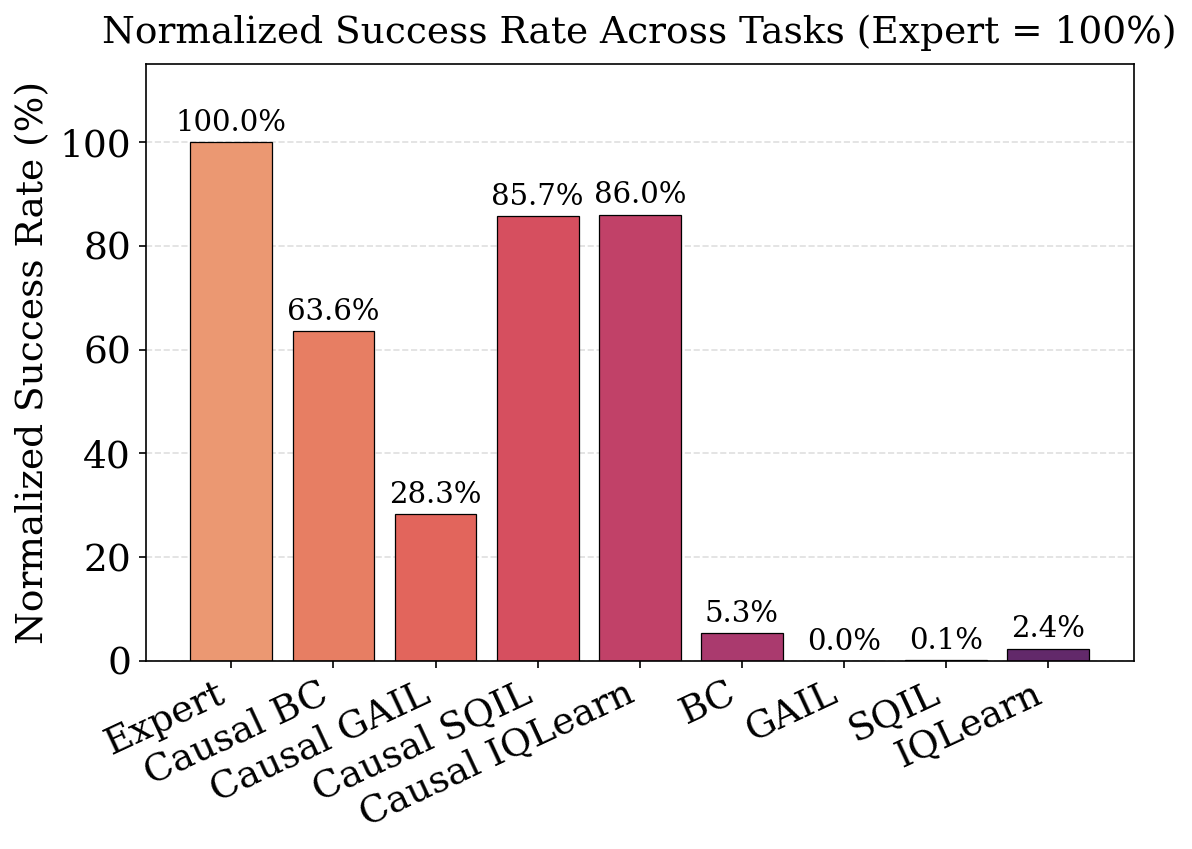

In [6]:
# --- Normalized Success Rate: Expert = 100% per task, then average across tasks ---

# Algorithm names (same order, skip Expert for the bar chart)
algo_names = [
    'Expert',
    'Causal BC', 'Causal GAIL', 'Causal SQIL', 'Causal IQLearn',
    'BC',  'GAIL',  'SQIL',  'IQLearn',
]

# Normalize each task's success rates so Expert = 100%
antlarge_norm = antlarge_success_rates / antlarge_success_rates[0] * 100  # Expert = 100
antmed_norm   = antmed_success_rates   / antmed_success_rates[0]   * 100  # Expert = 100
hummed_norm   = hummed_success_rates   / hummed_success_rates[0]   * 100

# Stack and average across tasks
all_norm = np.vstack([antlarge_norm, antmed_norm, hummed_norm])  # (n_tasks, n_algos)
avg_norm = all_norm.mean(axis=0)

x_all = np.arange(len(algo_names))

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(x_all, avg_norm, color=sns.color_palette("flare", 9), edgecolor='black', linewidth=0.6)
ax.set_xticks(x_all)
ax.set_xticklabels(algo_names, rotation=25, ha='right')
ax.set_ylabel('Normalized Success Rate (%)')
ax.set_title('Normalized Success Rate Across Tasks (Expert = 100%)', pad=10)
for bar, v in zip(bars, avg_norm):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.0, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=14)
ax.set_ylim(0, 115)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/normalized_success_rate_avg.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## Training vs. Runtime: Normalized E[Y] Drop

In [13]:
# --- Training vs Runtime: Normalized E[Y] comparison ---
# Data from results.md (Norm Best Training E[Y] and Norm E[Y] columns)

algorithms = ['CGAIL', 'CSQIL', 'CIQLearn', 'GAIL', 'SQIL', 'IQLearn']
algo_labels = ['Causal\nGAIL', 'Causal\nSQIL', 'Causal\nIQ-Learn', 'GAIL', 'SQIL', 'IQ-Learn']

# AntMaze Medium
antmed_train_norm = np.array([227.7781, 335.7881, 329.8181, 225.3281, 325.3881, 332.0281])
antmed_runtime_norm = np.array([239.4809, 275.7743, 257.1431, 10.4355, 4.6536, 2.7819])
antmed_drop = antmed_runtime_norm - antmed_train_norm

# AntMaze Large
antlarge_train_norm = np.array([184.9841, 299.5941, 289.7341, 175.2641, 224.5941, 250.8141])
antlarge_runtime_norm = np.array([155.6100, 204.2635, 225.5626, 85.7838, 0.0000, 16.0615])
antlarge_drop = antlarge_runtime_norm - antlarge_train_norm

# Use seaborn color palettes
ANTMED_RUNTIME_COLORS = sns.color_palette("flare", 6)
ANTLARGE_RUNTIME_COLORS = sns.color_palette("flare", 6)

x = np.arange(len(algorithms))

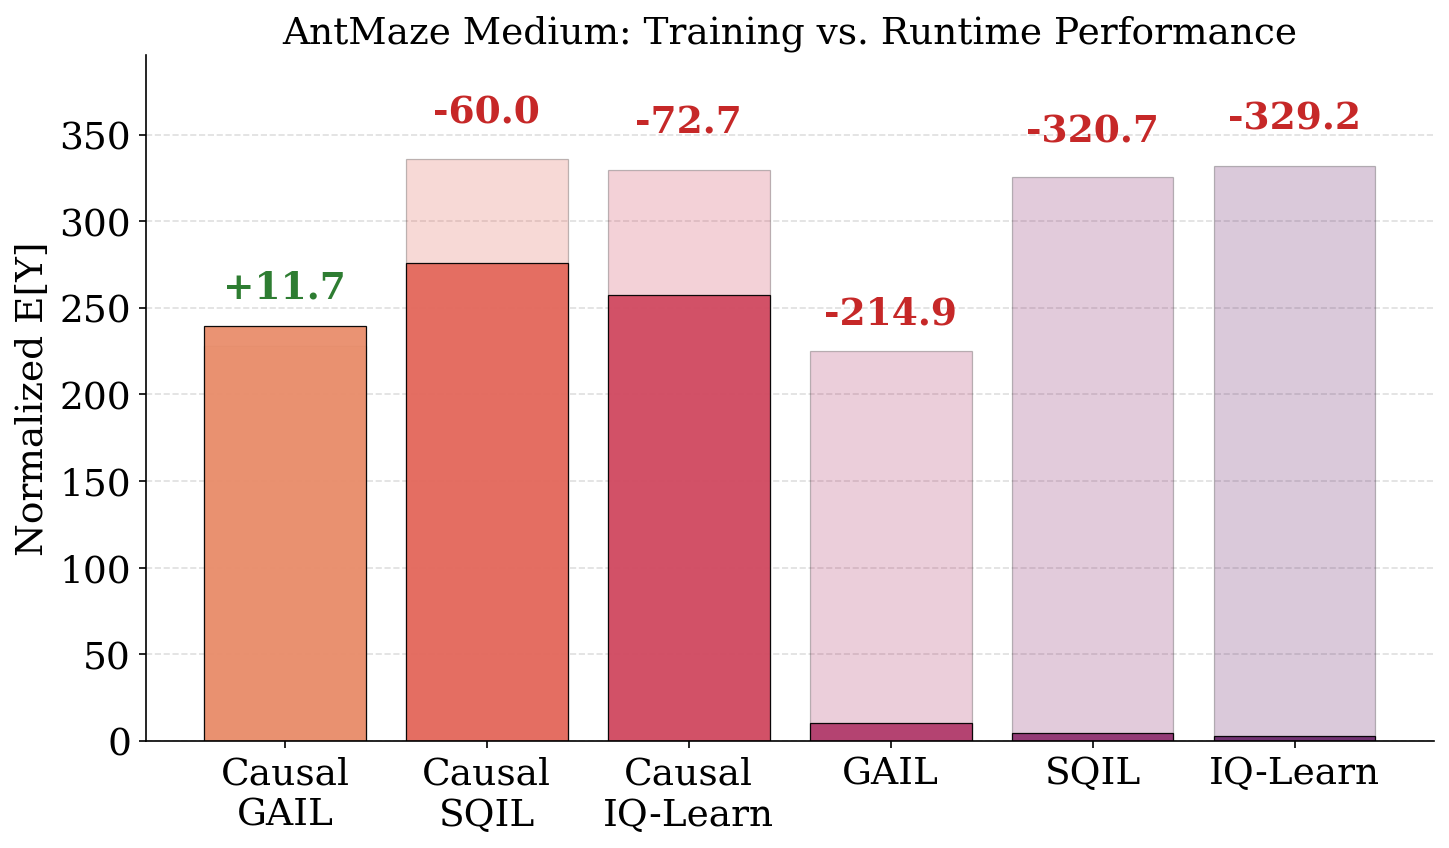

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.8

# Training (background)
ax.bar(
    x,
    antmed_train_norm,
    bar_width,
    color=ANTMED_RUNTIME_COLORS,
    edgecolor='black',
    linewidth=0.6,
    label='Best Training',
    alpha=0.25,
    zorder=1
)

# Runtime (foreground)
ax.bar(
    x,
    antmed_runtime_norm,
    bar_width,
    color=ANTMED_RUNTIME_COLORS,
    edgecolor='black',
    linewidth=0.6,
    label='Runtime (1000 eps)',
    alpha=0.95,
    zorder=2
)

# Difference labels
for i in range(len(x)):
    diff = antmed_drop[i]
    sign = '+' if diff >= 0 else ''
    y_pos = max(antmed_train_norm[i], antmed_runtime_norm[i]) * 1.05

    ax.text(
        x[i],
        y_pos,
        f'{sign}{diff:.1f}',
        ha='center',
        va='bottom',
        fontsize=18,
        fontweight='bold',
        color='#2E7D32' if diff >= 0 else '#C62828'
    )

ax.set_xticks(x)
ax.set_xticklabels(algo_labels)
ax.set_ylabel('Normalized E[Y]')
ax.set_title('AntMaze Medium: Training vs. Runtime Performance')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# paper-style spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(0, max(max(antmed_train_norm), max(antmed_runtime_norm)) * 1.18)

plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_train_vs_runtime.pdf', dpi=300, bbox_inches='tight')
plt.show()

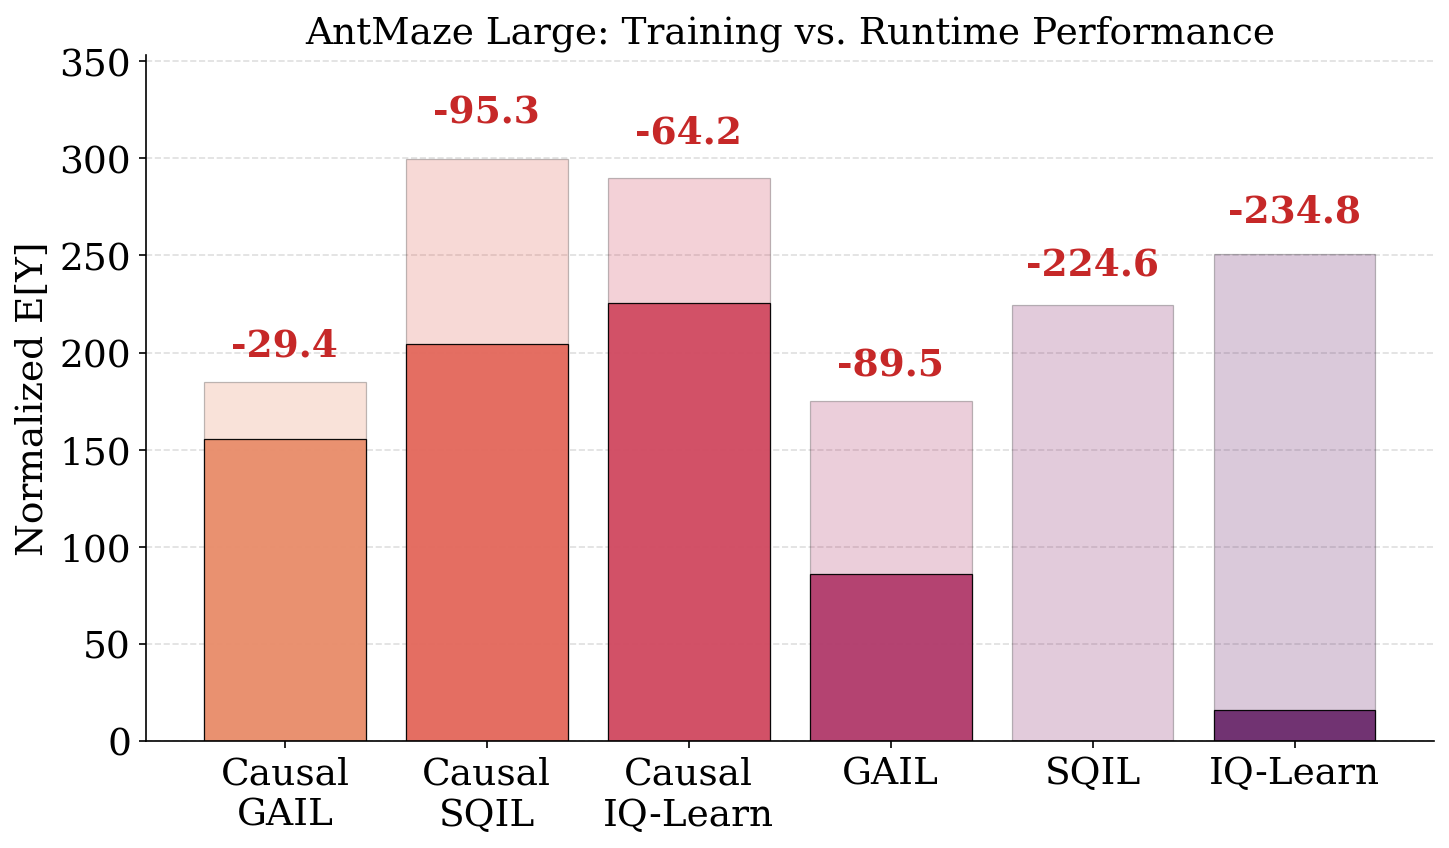

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.8

# Training
ax.bar(
    x,
    antlarge_train_norm,
    bar_width,
    color=ANTLARGE_RUNTIME_COLORS,
    edgecolor='black',
    linewidth=0.6,
    label='Best Training',
    alpha=0.25,
    zorder=1
)

# Runtime
ax.bar(
    x,
    antlarge_runtime_norm,
    bar_width,
    color=ANTLARGE_RUNTIME_COLORS,
    edgecolor='black',
    linewidth=0.6,
    label='Runtime (1000 eps)',
    alpha=0.95,
    zorder=2
)

# Difference labels
for i in range(len(x)):
    diff = antlarge_drop[i]
    sign = '+' if diff >= 0 else ''
    y_pos = max(antlarge_train_norm[i], antlarge_runtime_norm[i]) * 1.05

    ax.text(
        x[i],
        y_pos,
        f'{sign}{diff:.1f}',
        ha='center',
        va='bottom',
        fontsize=18,
        fontweight='bold',
        color='#2E7D32' if diff >= 0 else '#C62828'
    )

ax.set_xticks(x)
ax.set_xticklabels(algo_labels)
ax.set_ylabel('Normalized E[Y]')
ax.set_title('AntMaze Large: Training vs. Runtime Performance')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(0, max(max(antlarge_train_norm), max(antlarge_runtime_norm)) * 1.18)

plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antlarge_train_vs_runtime.pdf', dpi=300, bbox_inches='tight')
plt.show()